In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.metrics import mean_squared_error

In [2]:
apple = yf.download("AAPL", start = '2020-01-01', end = '2025-12-31')
apple.head(100)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200
...,...,...,...,...,...
2020-05-19,75.867554,77.171014,75.836056,76.325459,101729600
2020-05-20,77.343040,77.413296,76.686456,76.725222,111504800


In [3]:
print(apple.isna().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [4]:
apple.info()
apple.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1507 non-null   float64
 1   (High, AAPL)    1507 non-null   float64
 2   (Low, AAPL)     1507 non-null   float64
 3   (Open, AAPL)    1507 non-null   float64
 4   (Volume, AAPL)  1507 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.6 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1507.000000,1507.000000,1507.000000,1507.000000,1.507000e+03
mean,164.716562,166.399265,162.866330,164.554636,8.457532e+07
std,49.612317,49.903708,49.268797,49.567157,5.136009e+07
min,54.213608,55.211524,51.372088,55.110042,1.791060e+07
25%,131.293968,132.726015,129.931634,131.642322,5.077930e+07
50%,163.192932,165.182711,161.874907,163.432337,7.040420e+07
75%,196.961563,199.128040,194.486988,196.651569,1.005777e+08
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


### Closing Price Trend

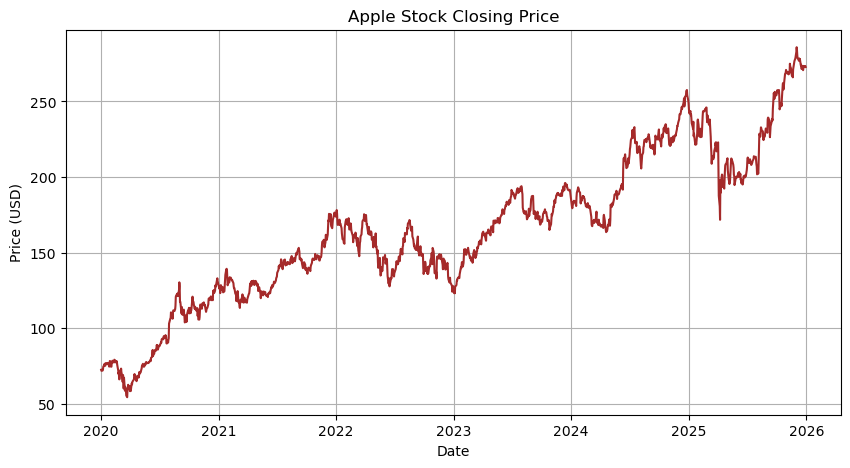

In [6]:
plt.figure(figsize = (10, 5))
plt.plot(apple['Close'], color = 'brown')
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()

### Moving Averages

In [8]:
apple['SMA50'] = apple['Close'].rolling(window=50).mean()
apple['SMA200'] = apple['Close'].rolling(window=200).mean()

apple[['Close', 'SMA50', 'SMA200']].tail(1000)

Price,Close,SMA50,SMA200
Ticker,AAPL,,
Date,,,
2022-01-05,171.165833,160.342193,141.417964
2022-01-06,168.308456,160.790315,141.674670
2022-01-07,168.474869,161.250951,141.929774
2022-01-10,168.494415,161.639280,142.181956
2022-01-11,171.322388,162.138301,142.447402
...,...,...,...
2025-12-23,272.105377,270.176155,229.717952
2025-12-24,273.554016,270.701263,229.986314


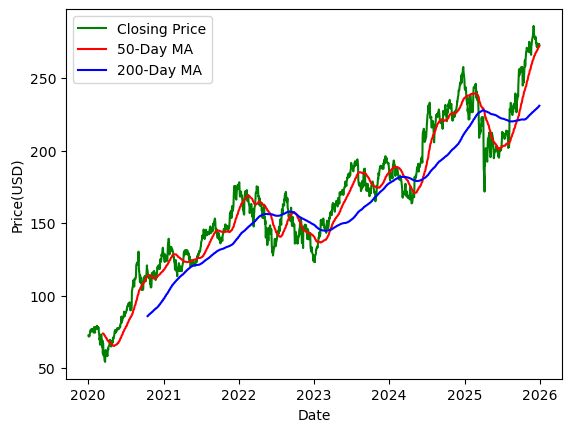

In [9]:
plt.plot(apple['Close'], label = 'Closing Price', color = 'green')
plt.plot(apple['SMA50'], label = '50-Day MA', color = 'red')
plt.plot(apple['SMA200'], label = '200-Day MA', color = 'blue')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.show()

### Daily Returns

In [11]:
apple['Daily Return'] = apple['Close'].pct_change()
print(apple['Daily Return'])

Date
2020-01-02         NaN
2020-01-03   -0.009722
2020-01-06    0.007968
2020-01-07   -0.004703
2020-01-08    0.016086
                ...   
2025-12-23    0.005130
2025-12-24    0.005324
2025-12-26   -0.001497
2025-12-29    0.001317
2025-12-30   -0.002484
Name: Daily Return, Length: 1507, dtype: float64


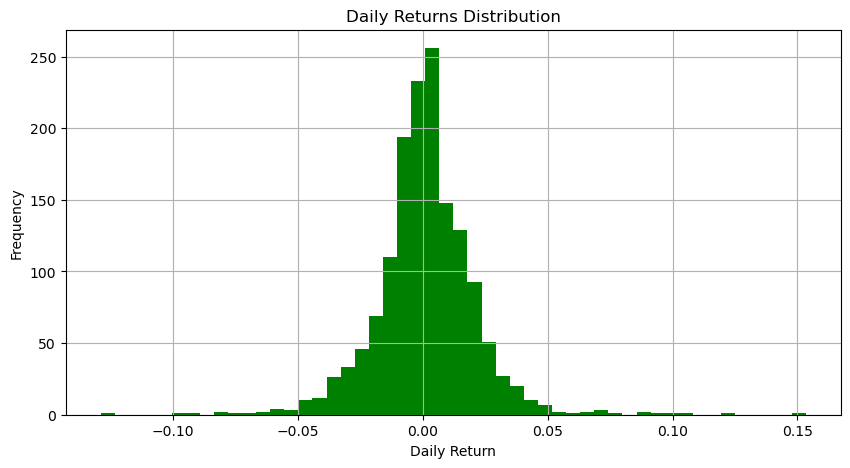

In [12]:
plt.figure(figsize = (10, 5))
apple['Daily Return'].hist(bins=50, color = 'green')
plt.title('Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [13]:
apple.head()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,-0.009722
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,0.007968
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,NaN,NaN,-0.004703
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,0.016086


### Risk vs Return

In [15]:
mean_return = apple['Daily Return'].mean()
risk = apple['Daily Return'].std()

print("Average Return:", mean_return)
print("Risk(Std Dev):", risk)

Average Return: 0.0010814157779956853
Risk(Std Dev): 0.02004424271461301


### Volume Analysis

In [17]:
apple.head()
print(apple.shape)
apple.columns = apple.columns.droplevel(1)
apple.columns
apple.head()

(1507, 8)


Price,Close,High,Low,Open,Volume,SMA50,SMA200,Daily Return
Date,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,-0.009722
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,0.007968
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,NaN,NaN,-0.004703
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,0.016086


Text(0, 0.5, 'Volume')

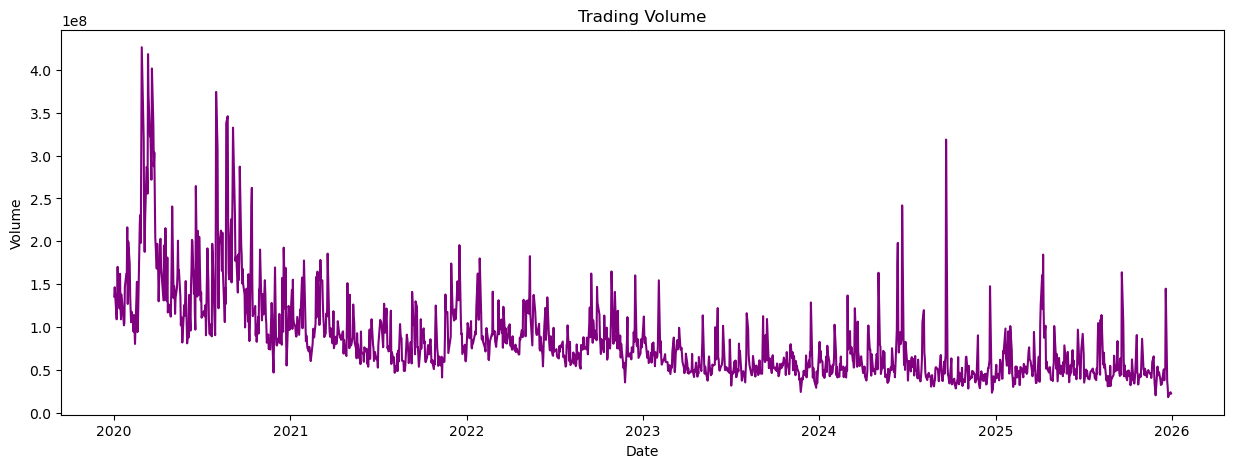

In [18]:
plt.figure(figsize = (15, 5))
plt.plot(apple['Volume'], color = 'purple')
plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

### Forecast

##### Split the Data

In [61]:
train_size = int(len(apple) * 0.8)

train = apple.iloc[:train_size].copy()
test = apple.iloc[train_size:].copy()

In [22]:
apple.head()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Daily Return
Date,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,-0.009722
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,0.007968
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,NaN,NaN,-0.004703
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,0.016086


#### Model 1 : Linear Regression

In [24]:
train['Days'] = np.arange(len(train))
test['Days'] = np.arange(train_size, len(apple))

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train[['Days']], train['Close'])

test['LR_Predict'] = lr.predict(test[['Days']])
test['LR_Predict']


Date
2024-10-16    208.669526
2024-10-17    208.770466
2024-10-18    208.871406
2024-10-21    208.972346
2024-10-22    209.073286
                 ...    
2025-12-23    238.648716
2025-12-24    238.749656
2025-12-26    238.850596
2025-12-29    238.951536
2025-12-30    239.052476
Name: LR_Predict, Length: 302, dtype: float64

In [26]:
mse = mean_squared_error(test['Close'], test['LR_Predict'])
print("Linear Regression MSE:", mse)

Linear Regression MSE: 569.6555166682424


In [27]:
apple.head()

Price,Close,High,Low,Open,Volume,SMA50,SMA200,Daily Return
Date,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,-0.009722
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,0.007968
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000,NaN,NaN,-0.004703
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,0.016086


#### Model 2 : Lag Model

In [29]:
apple_lag = apple[['Close']].copy()

apple_lag['Lag1'] = apple_lag['Close'].shift(1)
apple_lag['Lag2'] = apple_lag['Close'].shift(2)
apple_lag['Lag3'] = apple_lag['Close'].shift(3)
apple_lag = apple_lag.dropna()

In [47]:
train_size = int(len(apple_lag) * 0.8)

train = apple_lag.iloc[:train_size].copy()
test = apple_lag.iloc[train_size:].copy()

In [49]:
X1_train = train[['Lag1']]
X1_test = test[['Lag1']]

Y_train = train['Close']
Y_test = test['Close']

model1 = LinearRegression()
model1.fit(X1_train, Y_train)
test['Lag1_predict'] = model1.predict(X1_test)

In [32]:
X2_train = train[['Lag1', 'Lag2']]
X2_test = test[['Lag1', 'Lag2']]

model2 = LinearRegression()
model2.fit(X2_train, Y_train)
test['Lag12_predict'] = model2.predict(X2_test)

In [33]:
X3_train = train[['Lag1', 'Lag2', 'Lag3']]
X3_test = test[['Lag1', 'Lag2', 'Lag3']]

model3 = LinearRegression()
model3.fit(X3_train, Y_train)
test['Lag123_predict'] = model3.predict(X3_test)


In [34]:
mse1 = mean_squared_error(Y_test, test['Lag1_predict'])
mse2 = mean_squared_error(Y_test, test['Lag12_predict'])
mse3 = mean_squared_error(Y_test, test['Lag123_predict'])

print("MSE Lag1:", mse1)
print("MSE Lag1 + Lag2:", mse2)
print("MSE Lag1 + Lag2 + Lag3:", mse3)

MSE Lag1: 16.394228866623287
MSE Lag1 + Lag2: 16.45796206135977
MSE Lag1 + Lag2 + Lag3: 16.544198034712966


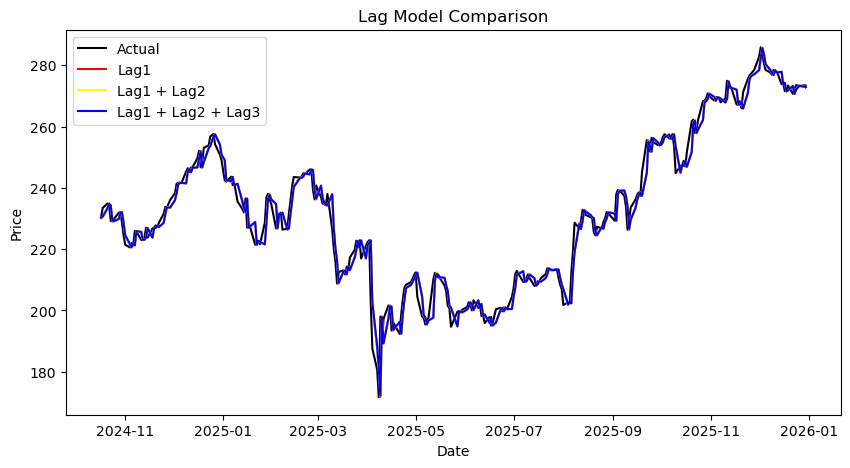

In [35]:
plt.figure(figsize = (10, 5))

plt.plot(test['Close'], label = 'Actual', color = 'black')
plt.plot(test['Lag1_predict'], label = 'Lag1', color = 'red')
plt.plot(test['Lag12_predict'], label = 'Lag1 + Lag2', color = 'yellow')
plt.plot(test['Lag123_predict'], label = 'Lag1 + Lag2 + Lag3', color = 'blue')

plt.title('Lag Model Comparison')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


#### Model 3 : ARIMA

In [37]:
train_size = int(len(apple) * 0.8)

train = apple.iloc[:train_size].copy()
test = apple.iloc[train_size:].copy()

In [38]:
from statsmodels.tsa.stattools import adfuller
clean_data = train['Close'].dropna()
result = adfuller(clean_data)
print('p-value:', result[1])

p-value: 0.7571298004263717


<Figure size 300x100 with 0 Axes>

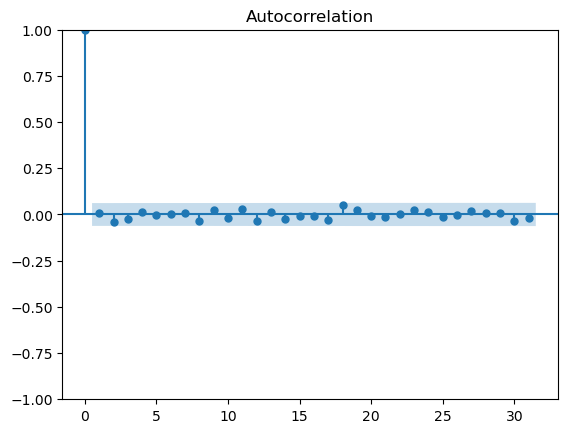

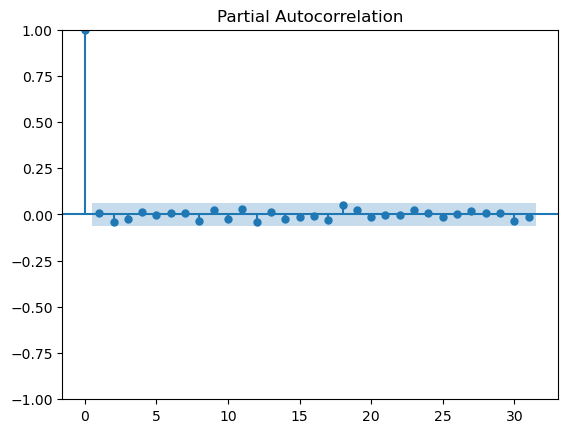

In [39]:
train['Close_diff'] = train['Close'].diff()
train = train.dropna()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize = (3,1))
plot_acf(train['Close_diff'])
plot_pacf(train['Close_diff'])
plt.show()

In [40]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Close'], order = (0,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps = len(test))
test['ARIMA_predict'] = forecast.values

C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

In [41]:
models = [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]

for order in models:
    model = ARIMA(train['Close'], order = order)
    model_fit = model.fit()

    forecast = model_fit.forecast(steps = len(test))
    forecast.index = test.index

    mse = mean_squared_error(test['Close'], forecast)
    print(f"ARIMA{order} MSE:", mse)

C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\U

ARIMA(0, 1, 0) MSE: 601.5583349262297
ARIMA(1, 1, 0) MSE: 601.5662512962427
ARIMA(0, 1, 1) MSE: 601.5667571860427
ARIMA(1, 1, 1) MSE: 601.5773382680792


C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\madus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


#### Predict Future Price

In [43]:
last_lag1 = apple['Close'].iloc[-1]

In [44]:
future_days = 10
future_preds = []


for i in range(future_days):
    lr_lag1 = LinearRegression()
    lr_lag1.fit(X1_train, Y_train)
    pred = lr_lag1.predict(pd.DataFrame([[last_lag1]], columns = ['Lag1']))[0]

    future_preds.append(pred)

    last_lag1 = pred

In [45]:
future_days = pd.date_range(start = apple.index[-1], periods = future_days + 1, freq = ('B'))[1:]

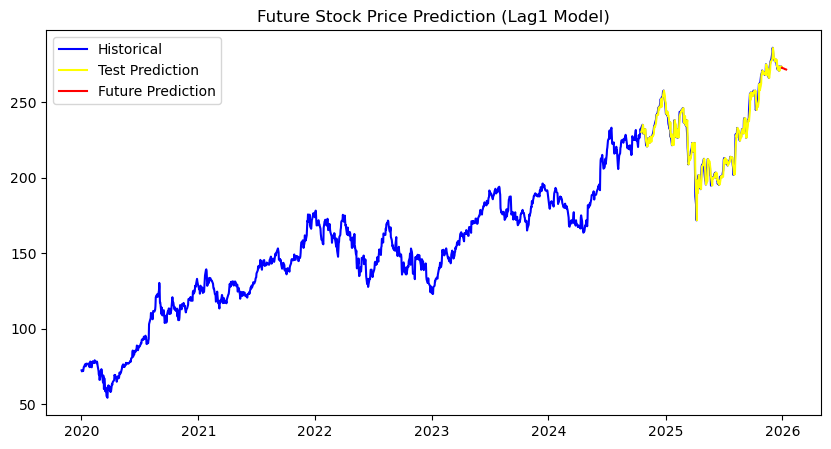

In [51]:
plt.figure(figsize = (10,5))

plt.plot(apple.index, apple['Close'], label = 'Historical', color = 'blue')
plt.plot(test.index, test['Lag1_predict'], label = 'Test Prediction', color = 'yellow' )
plt.plot(future_days, future_preds, label = 'Future Prediction', color = 'red')
plt.title("Future Stock Price Prediction (Lag1 Model)")
plt.legend()
plt.show()